# description

nice description here

# initial settings, packages

In [ ]:
# use conda environment: celldive00_rapidsai
print('november')

november


In [ ]:
# import packages
from tifffile import TiffFile
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.transform import rescale
from tqdm import tqdm  
import pandas as pd
import time
import cupy as cp
import pickle
import types
import os
# from concurrent.futures import ThreadPoolExecutor  
# from multiprocessing import Pool 
import seaborn as sns
import scanpy as sc

import importlib
import my_functions
importlib.reload(my_functions)

# %load_ext line_profiler # only needed for profiling functions


<module 'my_functions' from '/data1/peerd/CellDive/SLIDE-0265_Final/analysis/my_functions.py'>

In [ ]:
# set directories 
raw_data_directory =  '../raw_data/' # filesep at end
core_npy_directory =  '../raw_data_modified/cores_npy/' # filesep at end
mask_directory =  '../raw_data_modified/masks_npy/' # filesep at end


In [ ]:
# load data
adata = sc.read('../preprocessed/03_adata.h5ad')

# single gene distributions

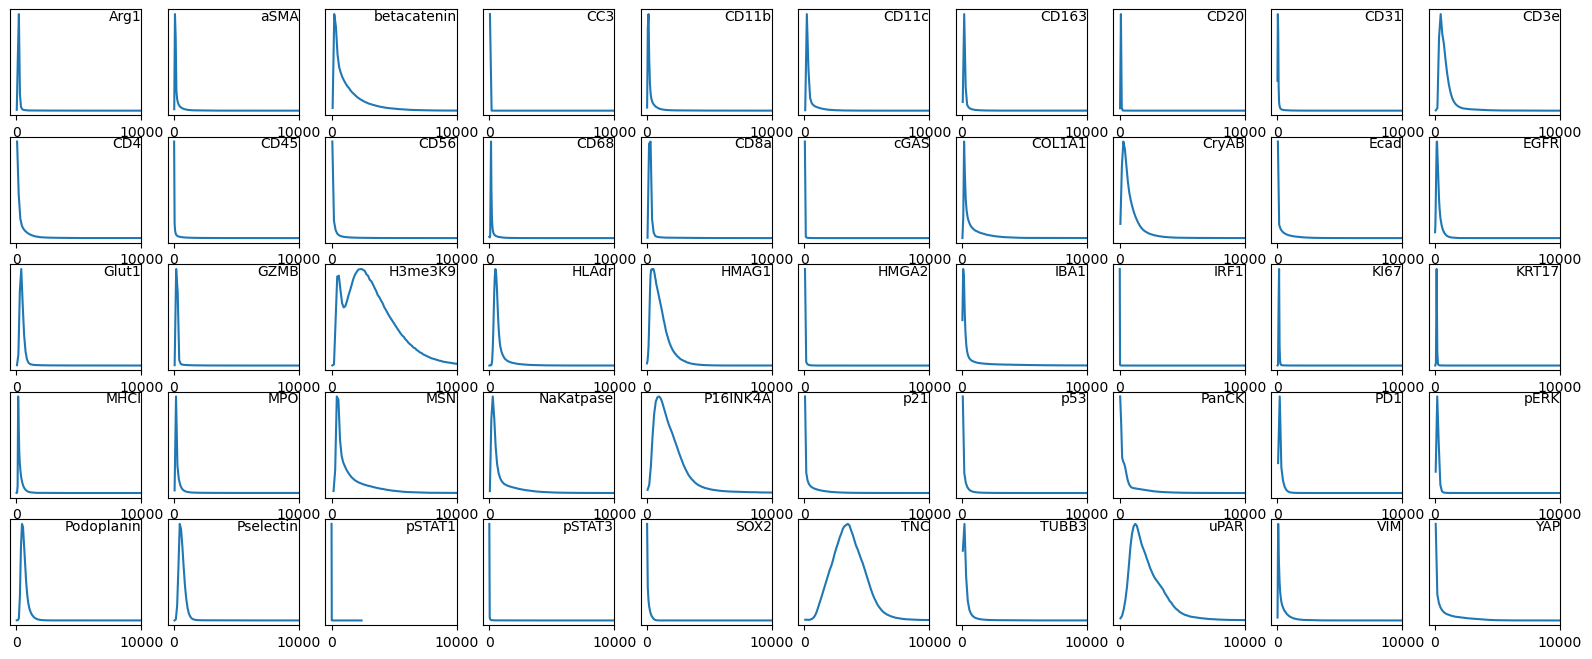

In [ ]:
_,ax_grid = plt.subplots(5,10,figsize=(20,8))
for counter,column in enumerate(adata.X.T):
    # calculate histogram
    data = column
    hist,bin_edges = np.histogram(data,500)
    bin_centers = (bin_edges[:-1] + bin_edges[1:])/2
    hist = hist / sum(hist) / (bin_edges[1]-bin_edges[0])
    
    # choose axes
    grid1 = counter % ax_grid.shape[1]
    grid0 = int((counter-grid1) / (ax_grid.shape[1]))
    ax = ax_grid[grid0,grid1]
    
    # plot
    ax.plot(bin_centers,hist)
    # ax.set_xlim([-10 , np.percentile(data,99.5)])
    ax.set_xlim([-500,10_000])
    ax.set_xticks([0,10_000]); ax.set_yticks([])
    ax.text(ax.get_xlim()[1],ax.get_ylim()[1],adata.var.index[counter],ha = 'right',va = 'top')
    
del ax_grid, counter, column, data, hist, bin_centers, bin_edges
del grid1, grid0,ax   



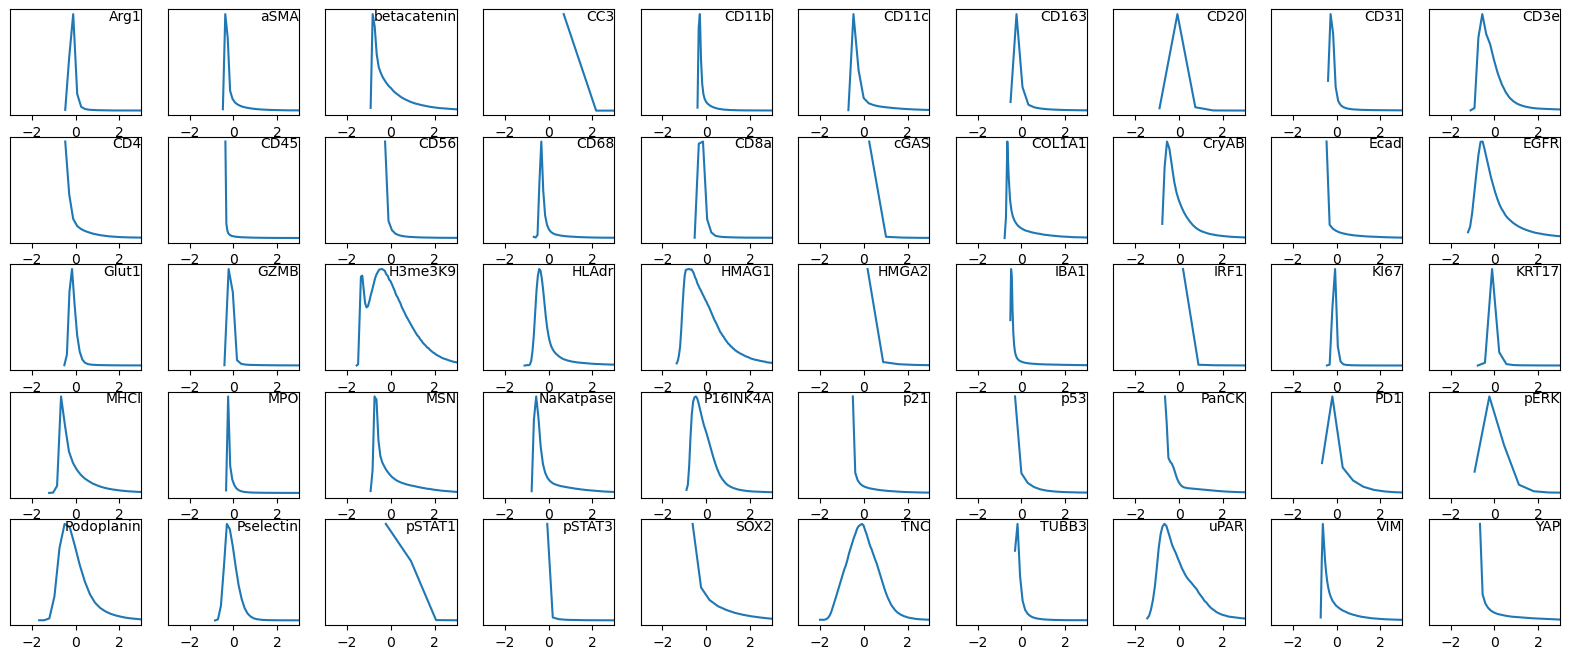

In [ ]:
_,ax_grid = plt.subplots(5,10,figsize=(20,8))
for counter,column in enumerate(adata.X.T):
    # transform data to have mean 0 , std 1 
    data = column.copy()
    data -= np.mean(data)
    data /= np.std(data)
    
    # calculate histogram
    hist,bin_edges = np.histogram(data,500)
    bin_centers = (bin_edges[:-1] + bin_edges[1:])/2
    hist = hist / sum(hist) / (bin_edges[1]-bin_edges[0])
    
    
    # choose axes
    grid1 = counter % ax_grid.shape[1]
    grid0 = int((counter-grid1) / (ax_grid.shape[1]))
    ax = ax_grid[grid0,grid1]
    
    # plot
    ax.plot(bin_centers,hist)
    # ax.set_xlim([-10 , np.percentile(data,99.5)])
    # ax.set_xlim([-200,custom_xlim[counter]])
    ax.set_xlim([-3,3])
    # ax.set_xticks([0,custom_xlim[counter]]); 
    ax.set_yticks([])
    ax.text(ax.get_xlim()[1],ax.get_ylim()[1],adata.var.index[counter],ha = 'right',va = 'top')

del ax_grid, counter, column, data, hist, bin_centers, bin_edges
del grid1, grid0,ax



# single gene correlations

In [ ]:
corr_matrix = np.corrcoef(adata.X, rowvar = False)

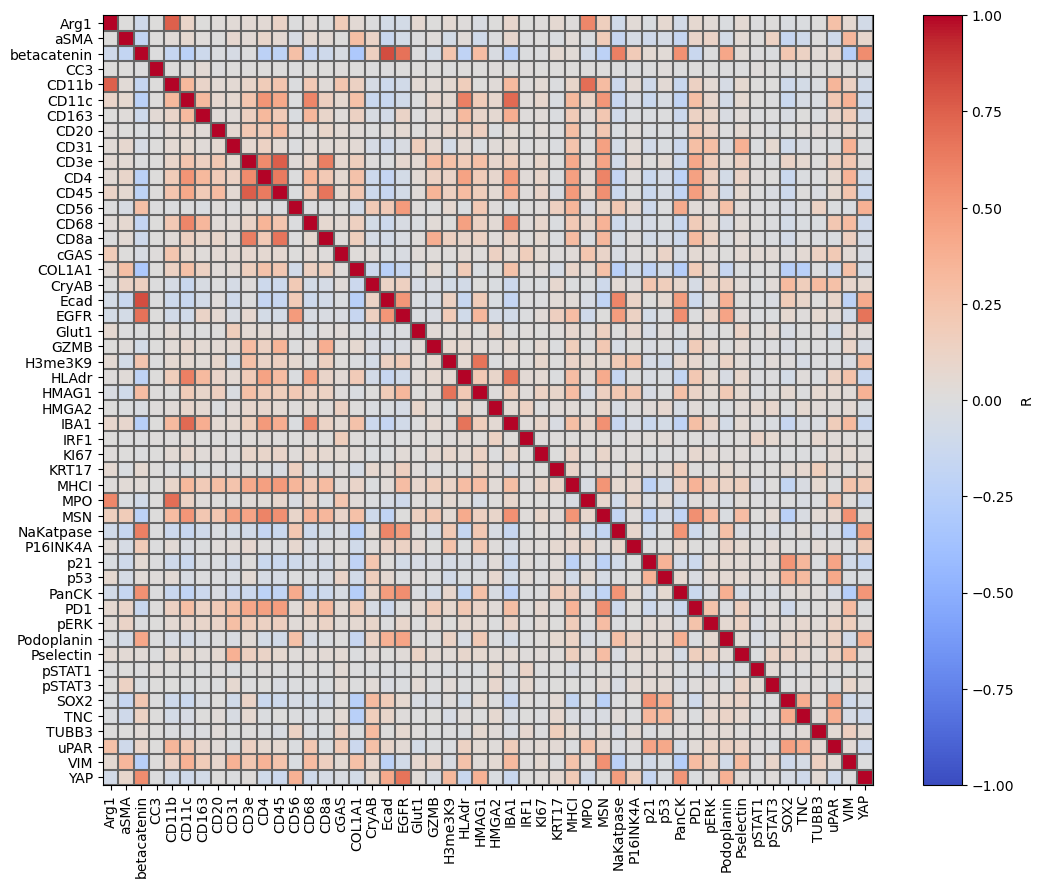

In [ ]:
fig,ax = plt.subplots(figsize = (13,10))
im = ax.imshow(corr_matrix,cmap='coolwarm',vmin = -1, vmax = 1)

# colorbar
cbar = fig.colorbar(im, ax=ax, label="R")

# axes labels
ax.set_xticks(np.linspace(0,adata.shape[1]-1,adata.shape[1]))
ax.set_xticklabels(adata.var.index,rotation = 90,ha = 'center')
ax.set_yticks(np.linspace(0,adata.shape[1]-1,adata.shape[1]))
ax.set_yticklabels(adata.var.index)

# grid lines
for counter0 in range(adata.shape[1]):
    # for counter1 in range(adata.shape[1]):
    ax.plot([ax.get_xlim()[0],ax.get_xlim()[1]],[counter0+0.5,counter0+0.5],c = [0.4,0.4,0.4])
    ax.plot([counter0+0.5,counter0+0.5],[ax.get_ylim()[0],ax.get_ylim()[1]],c = [0.4,0.4,0.4])

del fig,ax,im,cbar,counter0

    

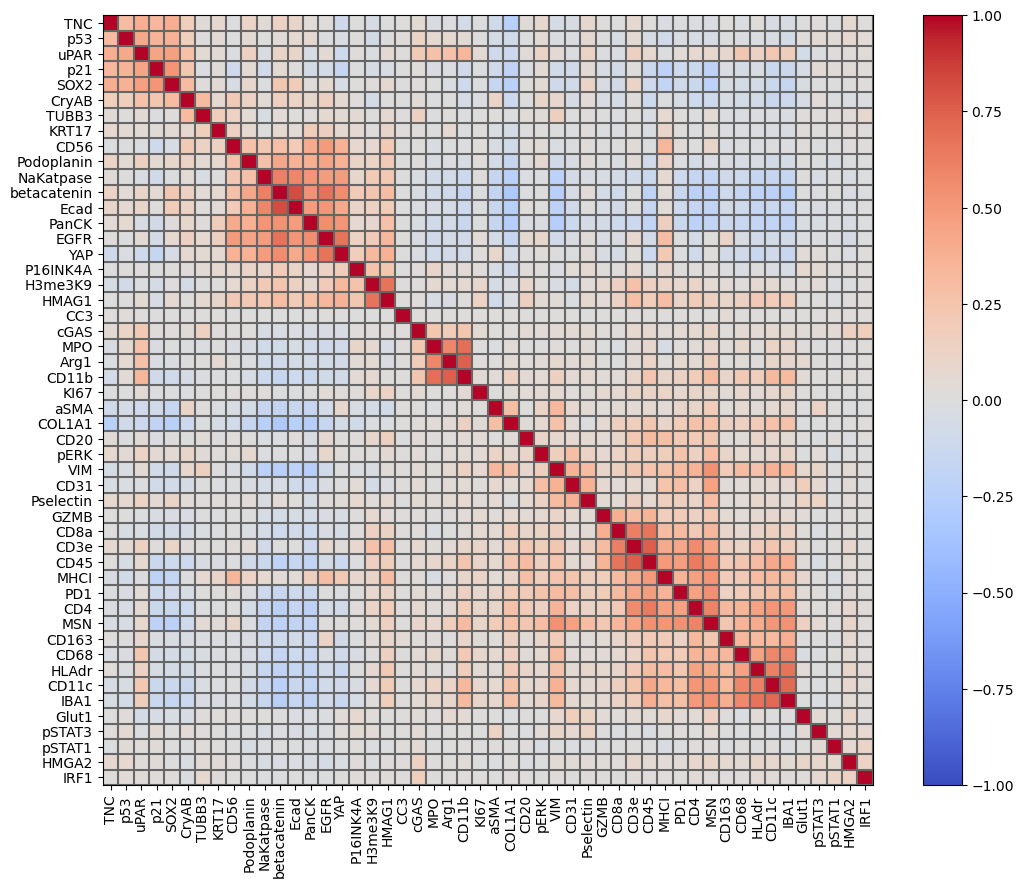

In [ ]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# 1. Convert correlation to a distance metric (1 - correlation)
#    Use only upper triangle (no duplication)
dist_matrix = 1 - corr_matrix
condensed_dist = squareform(dist_matrix, checks=False)

# 2. Perform hierarchical clustering
linkage_matrix = linkage(condensed_dist, method="average")

# 3. Get order of leaves (best column/row order)
order = leaves_list(linkage_matrix)

# 4. Reorder matrix
corr_matrix_reordered = corr_matrix[order][:, order]

# 5. Plot
fig, ax = plt.subplots(figsize = (13,10))
im = ax.imshow(corr_matrix_reordered, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(im, ax=ax)

ax.set_xticks(np.linspace(0,adata.shape[1]-1,adata.shape[1]))
ax.set_xticklabels(adata.var.index[order],rotation = 90,ha = 'center')
ax.set_yticks(np.linspace(0,adata.shape[1]-1,adata.shape[1]))
ax.set_yticklabels(adata.var.index[order])

# grid lines
for counter0 in range(adata.shape[1]):
    # for counter1 in range(adata.shape[1]):
    ax.plot([ax.get_xlim()[0],ax.get_xlim()[1]],[counter0+0.5,counter0+0.5],c = [0.4,0.4,0.4])
    ax.plot([counter0+0.5,counter0+0.5],[ax.get_ylim()[0],ax.get_ylim()[1]],c = [0.4,0.4,0.4])
    
del ax, condensed_dist, linkage_matrix, order, corr_matrix_reordered, dist_matrix
del fig, im, counter0

In [ ]:
# remove variables
del corr_matrix

# reorder adata genes based on relative correlation

In [ ]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

corr_matrix = np.corrcoef(adata.X, rowvar = False)
# 1. Convert correlation to a distance metric (1 - correlation)
#    Use only upper triangle (no duplication)
dist_matrix = 1 - corr_matrix
condensed_dist = squareform(dist_matrix, checks=False)

# 2. Perform hierarchical clustering
linkage_matrix = linkage(condensed_dist, method="average")

# 3. Get order of leaves (best column/row order)
order = leaves_list(linkage_matrix)

In [ ]:
order

array([45, 36, 47, 35, 44, 17, 46, 29, 12, 40, 33,  2, 18, 37, 19, 49, 34,
       22, 24,  3, 15, 31,  0,  4, 28,  1, 16,  7, 39, 48,  8, 41, 21, 14,
        9, 11, 30, 38, 10, 32,  6, 13, 23,  5, 26, 20, 43, 42, 25, 27],
      dtype=int32)

In [ ]:
adata.var_names[order]

Index(['TNC', 'p53', 'uPAR', 'p21', 'SOX2', 'CryAB', 'TUBB3', 'KRT17', 'CD56',
       'Podoplanin', 'NaKatpase', 'betacatenin', 'Ecad', 'PanCK', 'EGFR',
       'YAP', 'P16INK4A', 'H3me3K9', 'HMAG1', 'CC3', 'cGAS', 'MPO', 'Arg1',
       'CD11b', 'KI67', 'aSMA', 'COL1A1', 'CD20', 'pERK', 'VIM', 'CD31',
       'Pselectin', 'GZMB', 'CD8a', 'CD3e', 'CD45', 'MHCI', 'PD1', 'CD4',
       'MSN', 'CD163', 'CD68', 'HLAdr', 'CD11c', 'IBA1', 'Glut1', 'pSTAT3',
       'pSTAT1', 'HMGA2', 'IRF1'],
      dtype='object')

In [ ]:
adata2 = adata[:, adata.var_names[order]].copy()

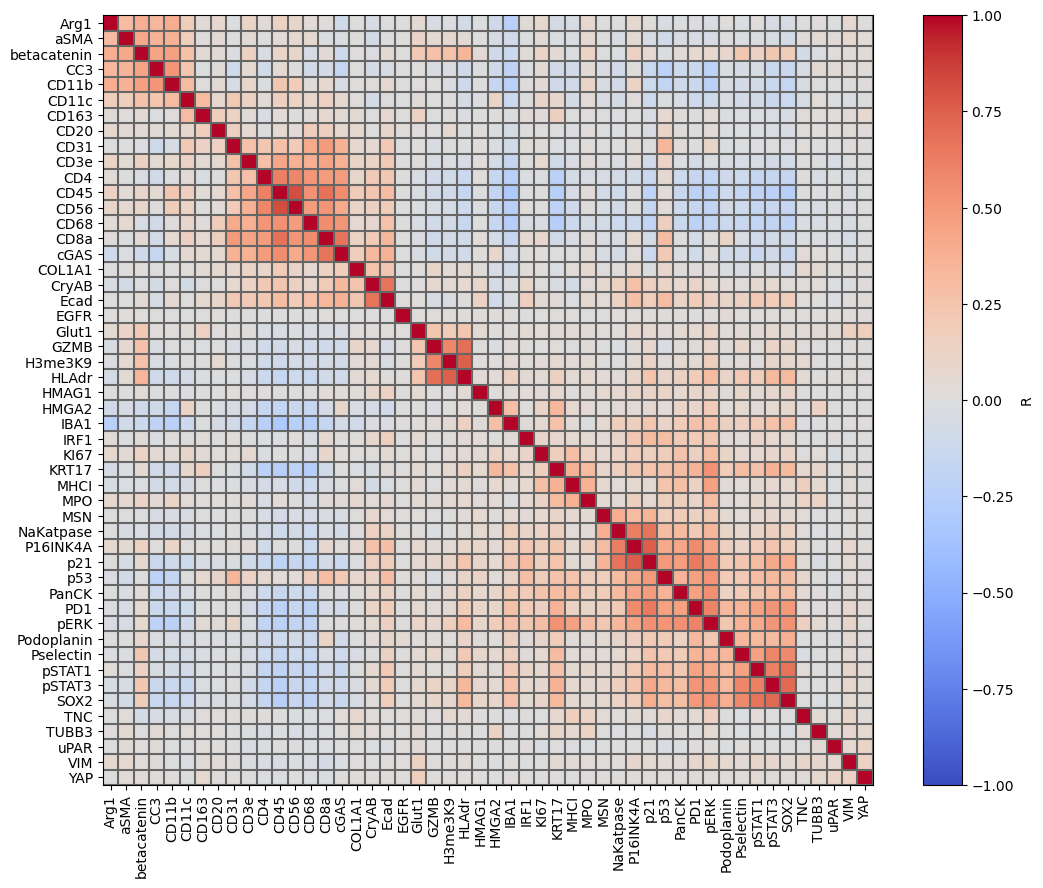

In [ ]:
corr_matrix = np.corrcoef(adata2.X, rowvar = False)

fig,ax = plt.subplots(figsize = (13,10))
im = ax.imshow(corr_matrix,cmap='coolwarm',vmin = -1, vmax = 1)

# colorbar
cbar = fig.colorbar(im, ax=ax, label="R")

# axes labels
ax.set_xticks(np.linspace(0,adata.shape[1]-1,adata.shape[1]))
ax.set_xticklabels(adata.var.index,rotation = 90,ha = 'center')
ax.set_yticks(np.linspace(0,adata.shape[1]-1,adata.shape[1]))
ax.set_yticklabels(adata.var.index)

# grid lines
for counter0 in range(adata.shape[1]):
    # for counter1 in range(adata.shape[1]):
    ax.plot([ax.get_xlim()[0],ax.get_xlim()[1]],[counter0+0.5,counter0+0.5],c = [0.4,0.4,0.4])
    ax.plot([counter0+0.5,counter0+0.5],[ax.get_ylim()[0],ax.get_ylim()[1]],c = [0.4,0.4,0.4])

del fig,ax,im,cbar,counter0

    

In [ ]:
# overwrite original adata
adata = adata2.copy()

In [ ]:
del corr_matrix, dist_matrix, order, condensed_dist, linkage_matrix, adata2

# normalization

In [ ]:
# set the raw layer, to save original count matrix
adata.layers['raw'] = adata.X.copy()

# zscore normalization
X = adata.layers['raw'].copy()
adata.layers['zscore'] = (X - np.mean(X, axis=0)) / np.std(X, axis=0, ddof=0)
del X

# Log-transformation (natural log, pseudocount of 1)
adata.layers['log1p'] = adata.layers['raw'].copy()
sc.pp.log1p(adata, layer='log1p')

# clustering

In [ ]:
def neighbors_gpu(mat, k=30):
    """Compute knn on a matrix using gpu

    Params:
        - mat: np.array
        - k: number of nearest neighbors
    Returns:
        tuple: distances and indices of knn (array format)
    """
    X_mat = cupy.array(mat)
    model = cuml.neighbors.NearestNeighbors(n_neighbors=k)
    model.fit(X_mat)
    distances, indices = model.kneighbors(X_mat)
    
# knn neighbors
import cuml

k = 30
X_mat = cp.array(adata.layers['zscore'])
model = cuml.neighbors.NearestNeighbors(n_neighbors=k)
model.fit(X_mat)
distances, indices = model.kneighbors(X_mat) # ~ 30-40 sec

del k,X_mat,model

In [ ]:
# edge graph
import cudf
import cugraph

mat = indices
targets = np.ravel(mat)
n_neighbors_per_cell = [len(x) for x in mat]
sources = np.ravel([[i] * k for i, k in zip(range(mat.shape[0]), n_neighbors_per_cell)])
edges = cudf.concat(
    [
        cudf.Series(sources.astype(np.int64), name="source"),  # sources
        cudf.Series(targets.astype(np.int64), name="destination"),  # targets
    ],
    axis=1,
)
G = cugraph.from_cudf_edgelist(edges) #~10-15 sec

del mat,targets, n_neighbors_per_cell,sources

In [ ]:
# jaccard graph
jaccard_edges = cugraph.jaccard(G, edges[['source', 'destination']])
G = cugraph.from_cudf_edgelist(jaccard_edges, *jaccard_edges.columns)

del jaccard_edges

In [ ]:
# louvain clustering
resolution = 1.0
result, score = cugraph.louvain(G, resolution = resolution)

In [ ]:
# Sort clusters by size
min_size = 0
sizes = result['partition'].value_counts()
sizes.loc[:] = cp.where(sizes > min_size, cp.arange(len(sizes)), -1)
result['partition'] = result['partition'].map(sizes)

In [ ]:
# Sort by vertex (e.g. cell)
clusters = result.sort_values('vertex')['partition'].values.get()

In [ ]:
adata.obs['phenograph_cluster'] = clusters

In [ ]:
from cuml.manifold import UMAP

def umap_gpu_preknn(X, knn_indices, knn_distances, n_components=2,
                    min_dist=0.1, metric = 'euclidean',random_state=0):
    """
    X: NumPy/CuPy (only used for shape; UMAP uses the precomputed KNN).
    knn_indices, knn_distances: CuPy int32/float32 of shape (n_samples, n_neighbors).
    """
    X_gpu = cp.asarray(X)  # ensures n_samples is known
    umap = UMAP(n_components=n_components,
                min_dist=min_dist,
                metric=metric,              # metric is ignored when precomputed_knn is used
                random_state=random_state,
                precomputed_knn=(knn_indices, knn_distances))
    embedding = umap.fit_transform(X_gpu)
    return embedding

umap = umap_gpu_preknn(adata.layers['zscore'], indices, distances)

[2025-10-20 17:52:07.274] [CUML] [info] build_algo set to brute_force_knn because random_state is given


In [ ]:
adata.obsm['umap'] = umap

In [ ]:
# remove variables
del clusters, distances, edges, G, indices, min_size
del resolution, result, score, sizes, UMAP, umap

# save adata

In [ ]:
# adata.write('../preprocessed/04_adata.h5ad')

In [ ]:
adata = sc.read('../preprocessed/04_adata.h5ad')

# plots

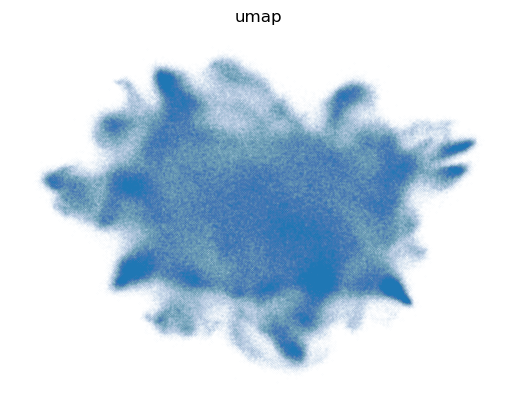

In [ ]:
umap = adata.obsm['umap']
x = umap[:,0].get()
y = umap[:,1].get()

_,ax = plt.subplots()
ax.scatter(x,y, s = 0.0001)
ax.set_title('umap'); ax.axis('off')

del ax, x, y, umap

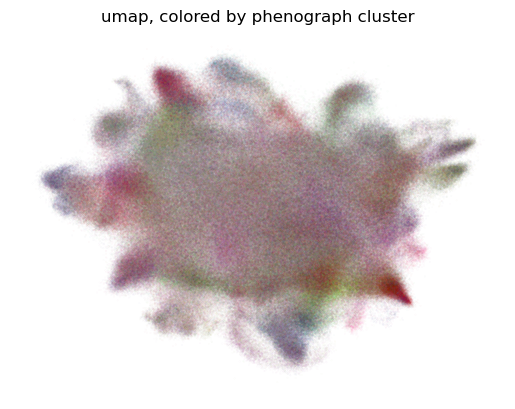

In [ ]:
x = umap[:,0].get()
y = umap[:,1].get()

clusters = np.sort(adata.obs['phenograph_cluster'].unique())
colors = np.random.rand(len(clusters),3)
colormap = adata.obs['phenograph_cluster'].map(lambda x: colors[x,:])

_,ax = plt.subplots()
ax.scatter(x,y, s = 0.0001, c = colormap)
ax.set_title('umap, colored by phenograph cluster'); ax.axis('off')

del ax, x, y, clusters, colors, colormap

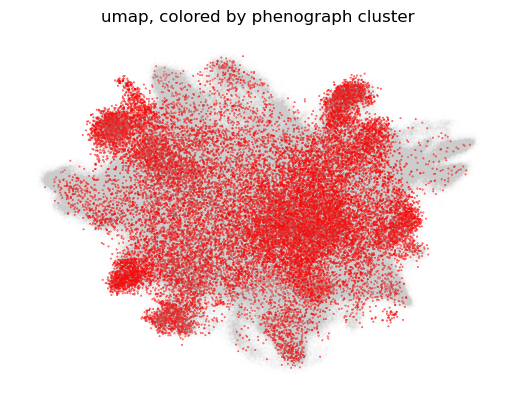

In [ ]:
x = umap[:,0].get()
y = umap[:,1].get()

core_id = 13
colormap = [[1,0,0] if x == core_id else [0.8,0.8,0.8]   for x in adata.obs['phenograph_cluster']]
sizes = [0.1 if x == core_id else 0.0001 for x in adata.obs['phenograph_cluster']]

_,ax = plt.subplots()
ax.scatter(x,y, s = sizes, c = colormap)
ax.set_title('umap, colored by phenograph cluster'); ax.axis('off')

del ax, x, y, core_id, colormap, sizes

68it [00:03, 17.96it/s]


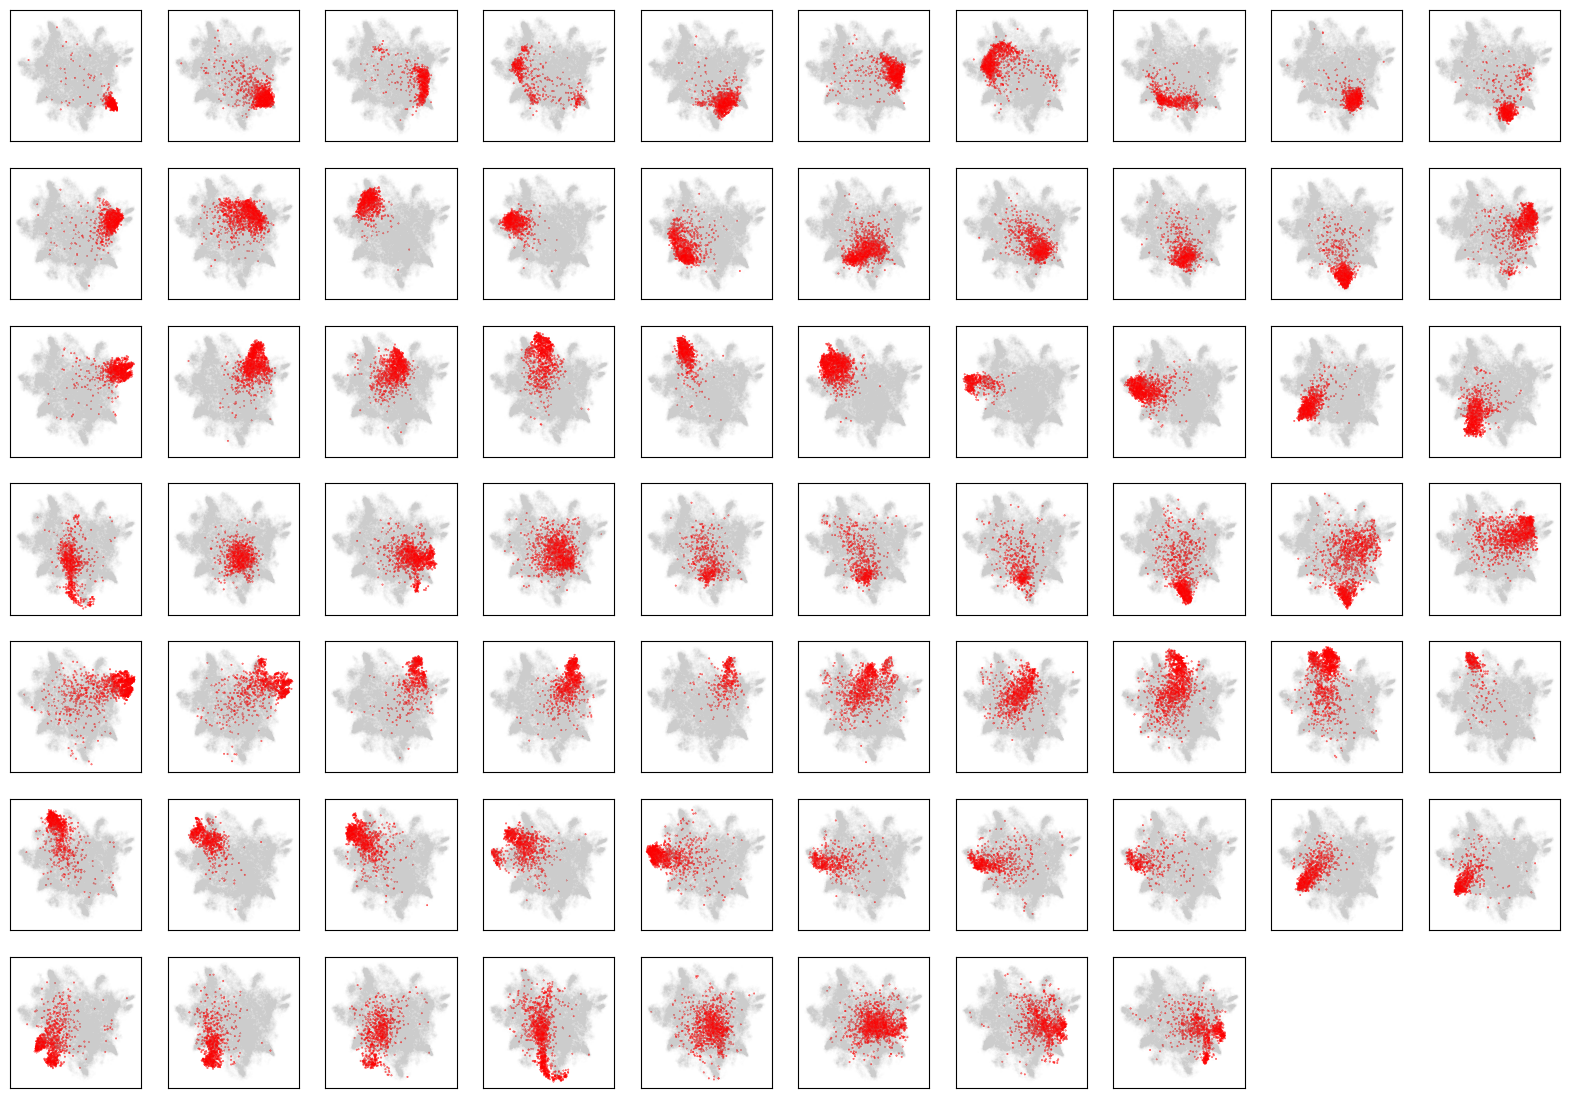

In [ ]:
# umap, colored by core
_, ax_grid = plt.subplots(7,10,figsize = (20,14))

x = adata.obsm['umap'][:,0].get()
y = adata.obsm['umap'][:,1].get()

core_ids = np.sort(adata.obs['core_id'].unique())
for counter,core_id in tqdm(enumerate(core_ids)):
    # choose axes
    grid1 = counter % ax_grid.shape[1]
    grid0 = int((counter - grid1)/ax_grid.shape[1])
    ax = ax_grid[grid0,grid1]
    
    # set color and size of scatter points, based on core id
    # c = [[1,0,0] if x == core_id else [0.8,0.8,0.8]   for x in adata.obs['phenograph_cluster']]
    # s = [0.1 if x == core_id else 0.0001 for x in adata.obs['phenograph_cluster']]
    mask = (adata.obs['core_id'] == core_id).values
    c = np.where(mask[:, None], [1, 0, 0], [0.8, 0.8, 0.8])
    s = np.where(mask, 0.1, 0.0001)
    
    # take subsample
    fraction = 0.05
    sample_size = int(np.floor(len(x) * fraction))
    idx = np.random.choice(len(x), size=sample_size, replace=False)
        
    ax.scatter(x[idx],y[idx],s =  s[idx], c = c[idx])
    ax.set_xticks([]); ax.set_yticks([])
    
# remove empty grids
counter += 1
while counter <= (ax_grid.size-1):
    grid1 = counter % ax_grid.shape[1]
    grid0 = int((counter - grid1)/ax_grid.shape[1])
    ax = ax_grid[grid0,grid1]
    ax.axis('off')
    counter+=1 
    
del ax_grid,x,y,core_ids,counter,core_id, grid1,grid0
del mask, c,s,fraction,sample_size,idx,ax


In [ ]:
list(np.sort(adata.obs['phenograph_cluster'].unique()))

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.i

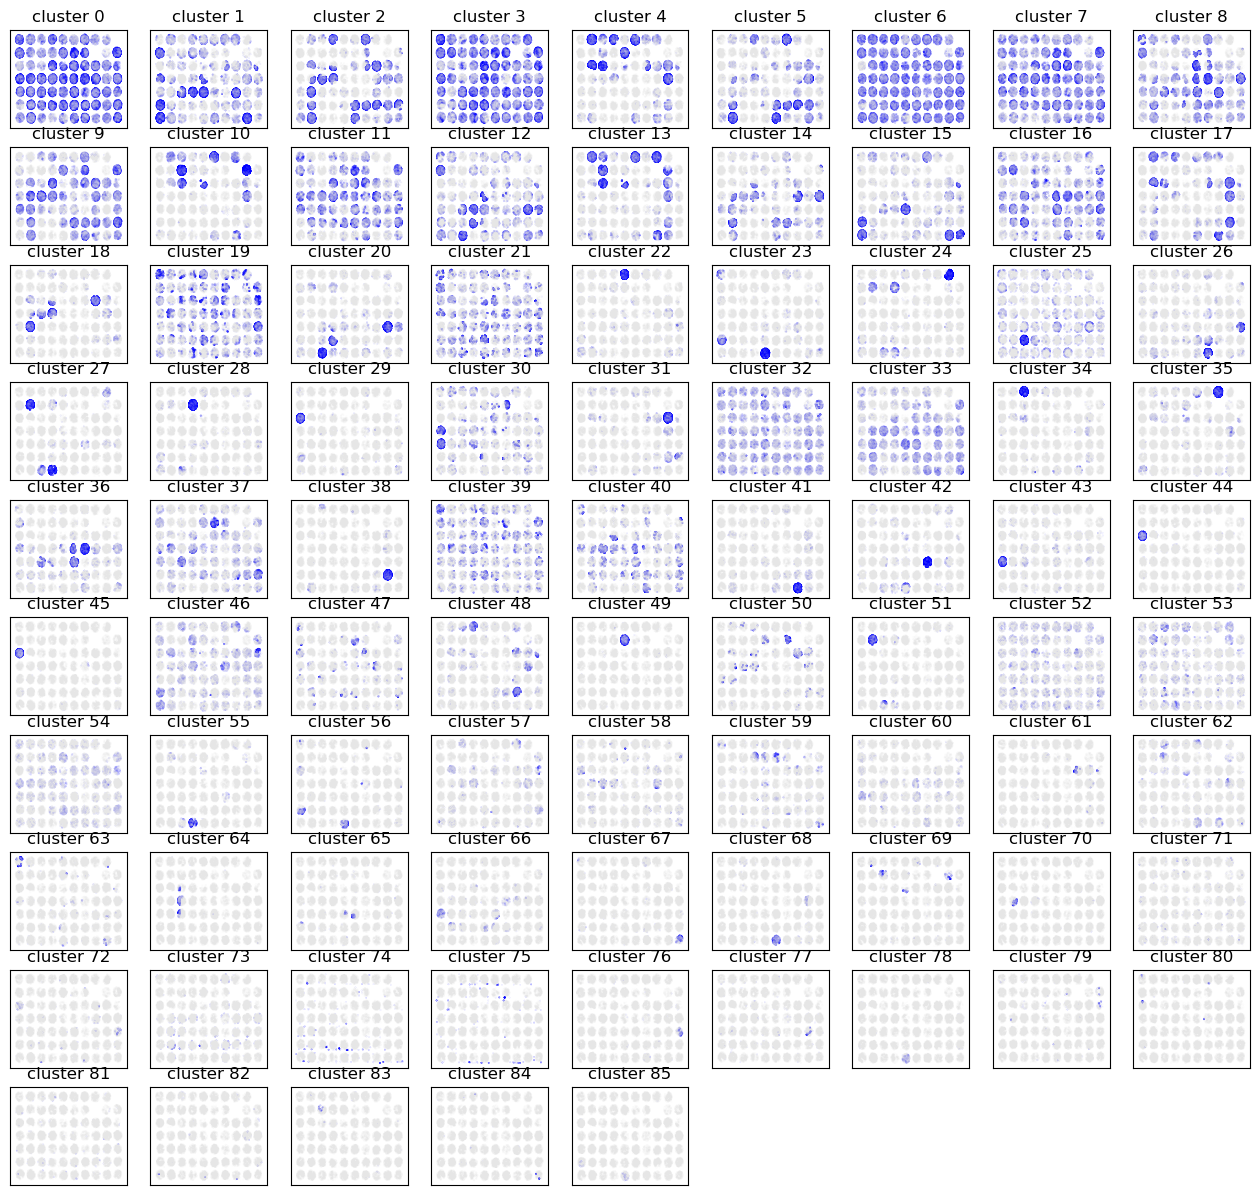

In [ ]:
cluster_list = list(np.sort(adata.obs['phenograph_cluster'].unique()))

# Precompute arrays once
y = adata.obs['centroid_row_global'].to_numpy()
x = adata.obs['centroid_col_global'].to_numpy()
adata_obs_clusters = adata.obs['phenograph_cluster'].to_numpy()

# Prepare figure grid
_, ax_grid = plt.subplots(10, 9, figsize=(16, 15))

# Precompute gray base color (as float32 for memory efficiency)
gray = np.array([0.9, 0.9, 0.9], dtype=np.float32)

for counter, cluster in enumerate(cluster_list[:]):
    # Select correct axis in grid
    grid1 = counter % ax_grid.shape[1]
    grid0 = counter // ax_grid.shape[1]
    ax = ax_grid[grid0, grid1]
    
    # Boolean mask (into adata) for points that match the cluster
    mask_cluster = (adata_obs_clusters == cluster)

    # Keep all indices (i.e. row indices of adata) for the selected cluster
    idx_cluster = np.where(mask_cluster)[0]

    # For non-cluster points, randomly subsample
    idx_non_cluster = np.where(~mask_cluster)[0]
    idx_non_cluster_subsample = np.random.choice(idx_non_cluster, size=20_000, replace=False)

    # Combine indices: cluster points + sampled background points
    idx_final = np.concatenate([idx_cluster, idx_non_cluster_subsample])
    
    # Create colors (vectorized instead of list comprehension)
    colors = np.full((adata_obs_clusters.shape[0], 3), 0.9)  # grey background
    colors[mask_cluster] = [0, 0, 1]  # blue for selected cluster

    # Plot
    ax.scatter(x[idx_final], y[idx_final], c=colors[idx_final], s=0.001) #, marker='.', linewidths=0, rasterized=True)    # ax.scatter(x[idx], y[idx], c=c[idx], s=0.001, marker='.', linewidths=0, rasterized=True)
    # ax.scatter(x, y, c=c, s=0.001, marker='.', linewidths=0, rasterized=True)
    # ax.scatter(x, y, c=c, s=0.001) #, marker='.', linewidths=0)
    ax.set_title(f"cluster {cluster}")
    ax.set_xticks([]); ax.set_yticks([])
    
counter += 1
while counter < ax_grid.size:
    # choose axes
    grid1 = counter % ax_grid.shape[1]
    grid0 = int((counter - grid1) / (ax_grid.shape[1]))
    ax = ax_grid[grid0,grid1]

    ax.axis('off')
    
    counter += 1
    
del cluster_list,x,y,ax_grid,gray,counter,cluster
del grid1, grid0,ax,idx_cluster,idx_non_cluster,idx_non_cluster_subsample
del idx_final, colors, mask_cluster, adata_obs_clusters

/tmp/ipykernel_1782808/736523270.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata.obs[grp]):


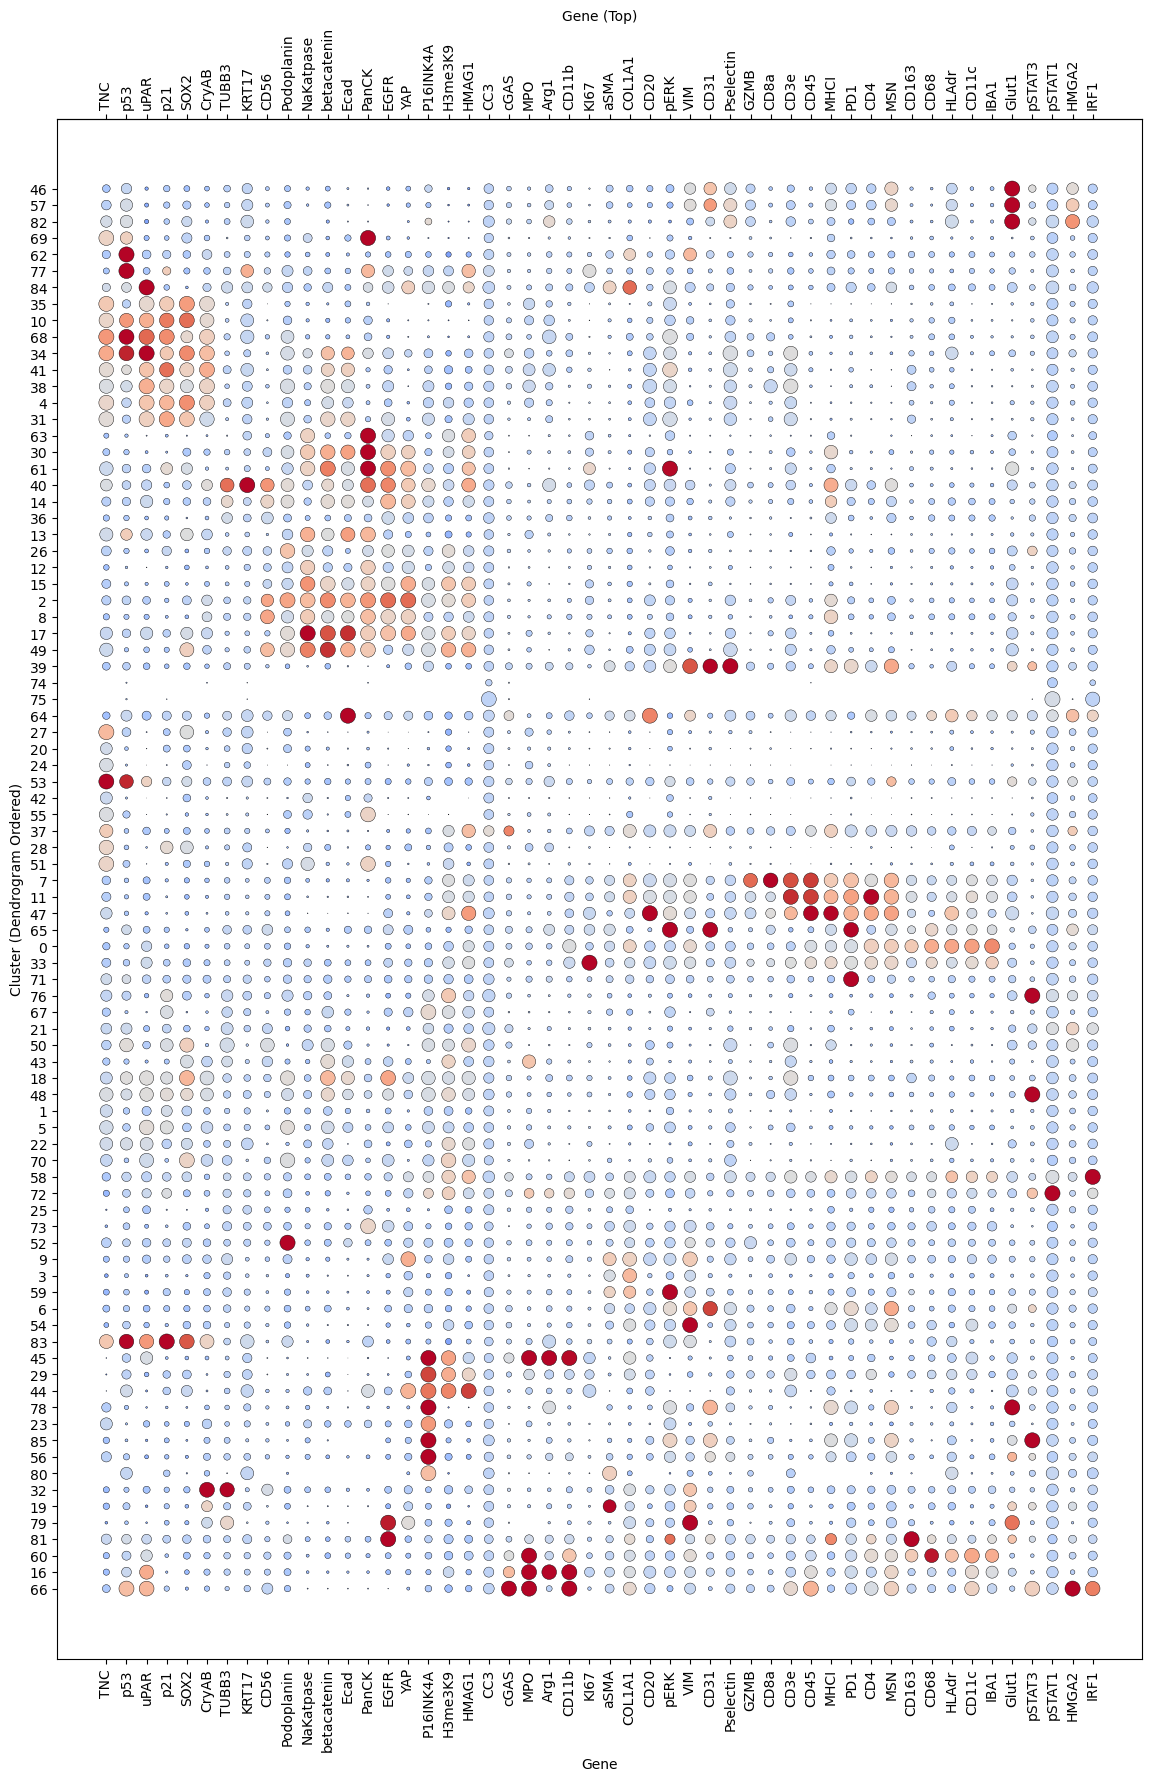

In [ ]:
# dotplot


# run dotplot, as to extract relevant data, but do not plot it
#  make groupby categorical
if not pd.api.types.is_categorical_dtype(adata.obs[grp]):
    cats = sorted(adata.obs[grp].unique())  # numeric order
    adata.obs[grp] = pd.Categorical(adata.obs[grp], categories=cats, ordered=True)

# (optional) precompute dendrogram; otherwise dotplot will try to do it
sc.tl.dendrogram(adata, groupby=grp)

dp = sc.pl.dotplot(
    adata,
    var_names=adata.var_names.to_list(),  # consider subsetting to your marker panel for speed
    groupby=grp,
    layer='zscore',
    return_fig=True,
    dendrogram=True
)

# 1. Extract core data
cluster_order = dp.categories_order  # Dendrogram-based cluster ordering
genes = dp.var_names
largest_dot = 120 # custom value, adjust as needed # dp.largest_dot if dp.largest_dot is not None else 200

# Reorder by dendrogram
mean_expr_df = dp.dot_color_df.loc[cluster_order] # dataframe, cluster by gene, entry is mean value 
fraction_df = dp.dot_size_df.loc[cluster_order]   # dataframe, cluster by gene, entry is fraction of values greater than 0

# 2. Compute plotted circle sizes 
circle_size_df = fraction_df.values * largest_dot # so dot size = fraction of entries greater than 0, times largest dot size
# circle_size_df = np.sqrt(fraction_df.values) * largest_dot # original

# 2.5. Scale mean_expr_df, i.e. dot colors
mean_expr_df = (mean_expr_df - -3)/(3 - -3) # dot color = mean expression of all z-score entries in cluster, then scaled between -3 and +3
mean_expr_df = np.clip(mean_expr_df,0,1)

# 3. Create a mesh grid for plotting positions
x_coords, y_coords = np.meshgrid(np.arange(len(genes)), np.arange(len(cluster_order)))

# Flatten for scatter plotting
x_flat = x_coords.flatten()
y_flat = y_coords.flatten()
sizes_flat = circle_size_df.flatten()
colors_flat = mean_expr_df.values.flatten()

# 4. Create the figure
fig, ax = plt.subplots(figsize=(14, 20))

scatter = ax.scatter(
    x_flat,
    y_flat,
    s=sizes_flat,          # Dot size
    c=colors_flat,         # Dot color = mean expression
    cmap= plt.get_cmap('coolwarm') , #dp.cmap,          # Match Scanpy's colormap
    edgecolors='black',
    linewidths=0.3
)

# 5. Format axes
ax.set_xticks(np.arange(len(genes)))
ax.set_xticklabels(genes, rotation=90)

ax.set_yticks(np.arange(len(cluster_order)))
ax.set_yticklabels(cluster_order)

# Flip the Y-axis so the first cluster is at the top
ax.invert_yaxis()

# === Add X-tick labels to the top ===
ax_top = ax.secondary_xaxis('top')  # Create a secondary x-axis
ax_top.set_xticks(np.arange(len(genes)))
ax_top.set_xticklabels(genes, rotation=90)
ax_top.set_xlabel("Gene (Top)")

ax.set_xlabel("Gene")
ax.set_ylabel("Cluster (Dendrogram Ordered)")

# 6. Add colorbar
# cbar = plt.colorbar()

del cluster_order, genes, largest_dot, mean_expr_df,fraction_df, circle_size_df
del x_coords, y_coords, x_flat, y_flat, sizes_flat, colors_flat
del fig, ax, scatter, ax_top

In [ ]:
def neighbors_gpu(mat, k=30):
    """Compute knn on a matrix using gpu

    Params:
        - mat: np.array
        - k: number of nearest neighbors
    Returns:
        tuple: distances and indices of knn (array format)
    """
    X_mat = cupy.array(mat)
    model = cuml.neighbors.NearestNeighbors(n_neighbors=k)
    model.fit(X_mat)
    distances, indices = model.kneighbors(X_mat)
    
# knn neighbors
import cuml

ad = adata[adata.obs['core_id'] == 27,:].copy()

k = 30
X_mat = cp.array(ad.layers['zscore'])
model = cuml.neighbors.NearestNeighbors(n_neighbors=k)
model.fit(X_mat)
distances, indices = model.kneighbors(X_mat) # ~ 30-40 sec

del k,X_mat,model

In [ ]:
from cuml.manifold import UMAP

def umap_gpu_preknn(X, knn_indices, knn_distances, n_components=2,
                    min_dist=0.1, metric = 'euclidean',random_state=0):
    """
    X: NumPy/CuPy (only used for shape; UMAP uses the precomputed KNN).
    knn_indices, knn_distances: CuPy int32/float32 of shape (n_samples, n_neighbors).
    """
    X_gpu = cp.asarray(X)  # ensures n_samples is known
    umap = UMAP(n_components=n_components,
                min_dist=min_dist,
                metric=metric,              # metric is ignored when precomputed_knn is used
                random_state=random_state,
                precomputed_knn=(knn_indices, knn_distances))
    embedding = umap.fit_transform(X_gpu)
    return embedding

umap = umap_gpu_preknn(ad.layers['zscore'], indices, distances)

[2025-10-27 17:01:16.113] [CUML] [info] build_algo set to brute_force_knn because random_state is given


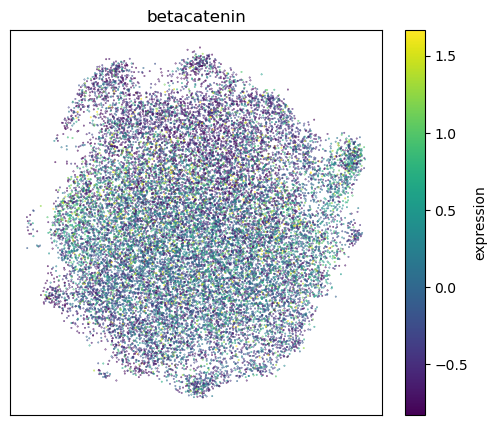

In [ ]:
def plot_umap(umap,ad,gene_strings):
    # umap is nx2 array
    # ad is anndata object
    # gene_strings is a list of string represent the gene by which to color 
    #   will also run fine if gene_strings is just the gene_name
    
    from matplotlib.cm import ScalarMappable

    cmap = plt.get_cmap('viridis')
    
    # get the number of genes
    if isinstance(gene_strings,str):
        gene_strings = [gene_strings] # handling case where gene_strings is just a single string, not even a list
    num_of_genes = len(gene_strings)
    
    # declare the axes object
    _,ax_grid = plt.subplots(1,num_of_genes,figsize=(6*num_of_genes,5)) # only 1d grid for now
    
    # loop thru all 
    for axes_counter in range(num_of_genes):
        # choose the axes object, careful here
        if num_of_genes == 1:
            ax = ax_grid
        else:
            ax = ax_grid[axes_counter]
        
        # set the gene for pseudocoloring
        gene_string = gene_strings[axes_counter]
    
        # create colormap, for pseudocoloring umap
        myvector = ad[:,gene_string].layers['zscore']
        myvector_min = np.percentile(myvector,1)
        myvector_max = np.percentile(myvector,99)
        myvector_scaled = (myvector - myvector_min)/(myvector_max-myvector_min)
        myvector_scaled = np.clip(myvector_scaled,0,1)

        myvector_colors = cmap(myvector_scaled)

    
        ax.scatter(umap[:,0],umap[:,1],s=0.1,color=myvector_colors)
        ax.set_xticklabels(''); ax.set_xticks([])
        ax.set_yticklabels(''); ax.set_yticks([])
        ax.set_title(gene_string)
        
        # Add colorbar
        norm = plt.Normalize(vmin=myvector_min, vmax=myvector_max)
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])  # needed for colorbar
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label(f"expression")

plot_umap(umap.get(), ad , 'betacatenin')

In [ ]:
def plot_cluster_on_box(adata,box_code_num,markers,cluster):
    # inputs:
    #   adata: anndata object, should have clusters already defined in adata.obs, like adata.obs['phenograph_cluster_zscore']
    #   box_code_num: integer, or number, that refers to specific box_code user desires to display
    #   markers: list of 3 strings, that denote which markers to plot, e.g. markers = ['upar','nak-atpase-555','dapi'], are R G B
    #   cluster: integer, defining which cluster to plot
    # output:
    #   ax: axes object to a plot, showing where the cluster is located inside user specified box

    # set directories for images to be analyzed
    image_directory =  '../raw_data_modified/cores_npy/' #filesep at end
    mask_directory = '../raw_data_modified/cores_npy/masks_npy/' #filesep at end
    phenograph_cluster = cluster

    # get the rgb image
    img_cp = my_functions.get_image(image_directory,box_code_num,markers)

    # get list of bounding boxes, for this particular box code
    bounding_box_list = my_functions.get_bounding_boxes(box_code_num,mask_directory,image_directory)

    # get list of cell indices that are in user specified cluster
    temp_mask = (adata.obs['phenograph_cluster'] == phenograph_cluster) & (adata.obs['box_code'] == box_code_num)
    ns_set= set(adata.obs['n'][temp_mask])

    # get list of mask outlines
    mask_outline_list = []
    for counter,item in tqdm(enumerate(bounding_box_list)):
        if item[0] in ns_set: # item[0] is the cell index
            mask_outline_list.append(my_functions.get_outline(item, thickness = 3))

    # define the red wires
    img_wires_cp = img_cp.copy()
    # img_redwires_cp *= 0
    pixels = np.vstack(mask_outline_list)
    img_wires_cp[pixels[:,1],pixels[:,0],:] = 1
    
    # define axes grid
    _,ax_grid = plt.subplots(1,2,figsize = (40,20))

    # display rgb image, without wires
    ax = ax_grid[0]
    ax.imshow(img_cp.get())
    ax.set_title(f"box{box_code_num:03} , R: {markers[0]}, G:{markers[1]}, B:{markers[2]}")
    ax.set_xticks([]); ax.set_yticks([])
    
    # display rgb image, with wires
    ax = ax_grid[1]
    ax.imshow(img_wires_cp.get())
    ax.set_title(f"cluster {phenograph_cluster}")
    ax.set_xticks([]); ax.set_yticks([])

    
# del cluster_list,x,y,ax_grid,gray,counter,cluster
# del grid1, grid0,ax,idx_cluster,idx_non_cluster,idx_non_cluster_subsample
# del idx_final, colors, mask_cluster

In [ ]:
markers = ['CD45','PanCK','dapi']
core_code_num = 2
cluster = 34

plot_cluster_on_box(adata,core_code_num,markers,cluster)

# testing

In [ ]:
def plot_individual_category(
    adata, 
    coord_name, 
    obs_name, 
    selected_values, 
    condition_colors, 
    alpha = 1, 
    s=0.1, 
    frameon=True, 
    figsize_max = 10, 
    ax = None,
    rasterized = True, 
    background_color = 'lightgray', 
    use_outlines = True, 
    axes_color = 'white'
):
    x = adata.obsm[coord_name][:,0]
    y = adata.obsm[coord_name][:,1]
    max_x = np.max(x) - np.min(x)
    max_y = np.max(y) - np.min(y)
    if(max_x > max_y):
        figsize = [figsize_max, figsize_max*max_y/max_x]
    else:
        figsize = [figsize_max*max_x/max_y, figsize_max]
    #figsize = [figsize_max, figsize_max]
    conditions = adata.obs[obs_name]
    colors = np.array([condition_colors[x] if x != None else 'lightgray' for x in ismember(conditions, selected_values)[0]])    
    subcells = ismember(conditions, selected_values)[1]
    point_order = np.random.permutation(np.sum(subcells))
    if ax is None:
        f, ax = plt.subplots(1,1,figsize=figsize, dpi=150)
        if(use_outlines):
            ax.scatter(x,y, facecolor='black', edgecolor='none', marker = 'o', linewidth=0, s=s*20, alpha = 1, rasterized = rasterized)
            ax.scatter(x,y, facecolor='white', edgecolor='none', marker = 'o', linewidth=0, s=s*10, alpha = 1, rasterized = rasterized)
        ax.scatter(x,y, facecolor=background_color, edgecolor='none', marker = 'o', linewidth=0, s=s*5, alpha = 1, rasterized = rasterized)
        if not frameon:
            ax.set_xticks([])
            ax.set_yticks([])
        ax.set_facecolor(axes_color)
    ax.scatter(x[subcells][point_order],y[subcells][point_order], facecolor=colors[subcells][point_order], edgecolor=None, linewidth=0, s=s*5, alpha = alpha, rasterized = rasterized)
    ax.grid(False)
    ax.margins(x=0, y=0)
    plt.axis('off')
    return(ax)

def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = np.array([bind.get(itm, None) for itm in a])  # None can be replaced by any other "not in b" value
    result = [result, np.array([not x is None for x in result])]
    return result

In [ ]:
adata.obsm['x_spatial_global'] = adata.obs[['centroid_row_global','centroid_col_global']].to_numpy()

adata

AnnData object with n_obs × n_vars = 1309024 × 50
    obs: 'core_id', 'cell_id', 'area', 'centroid_row_local', 'centroid_col_local', 'centroid_row_global', 'centroid_col_global', 'phenograph_cluster'
    var: 'placeholder'
    uns: 'log1p'
    obsm: 'umap', 'x_spatial_global'
    layers: 'log1p', 'raw', 'zscore'

<Axes: >

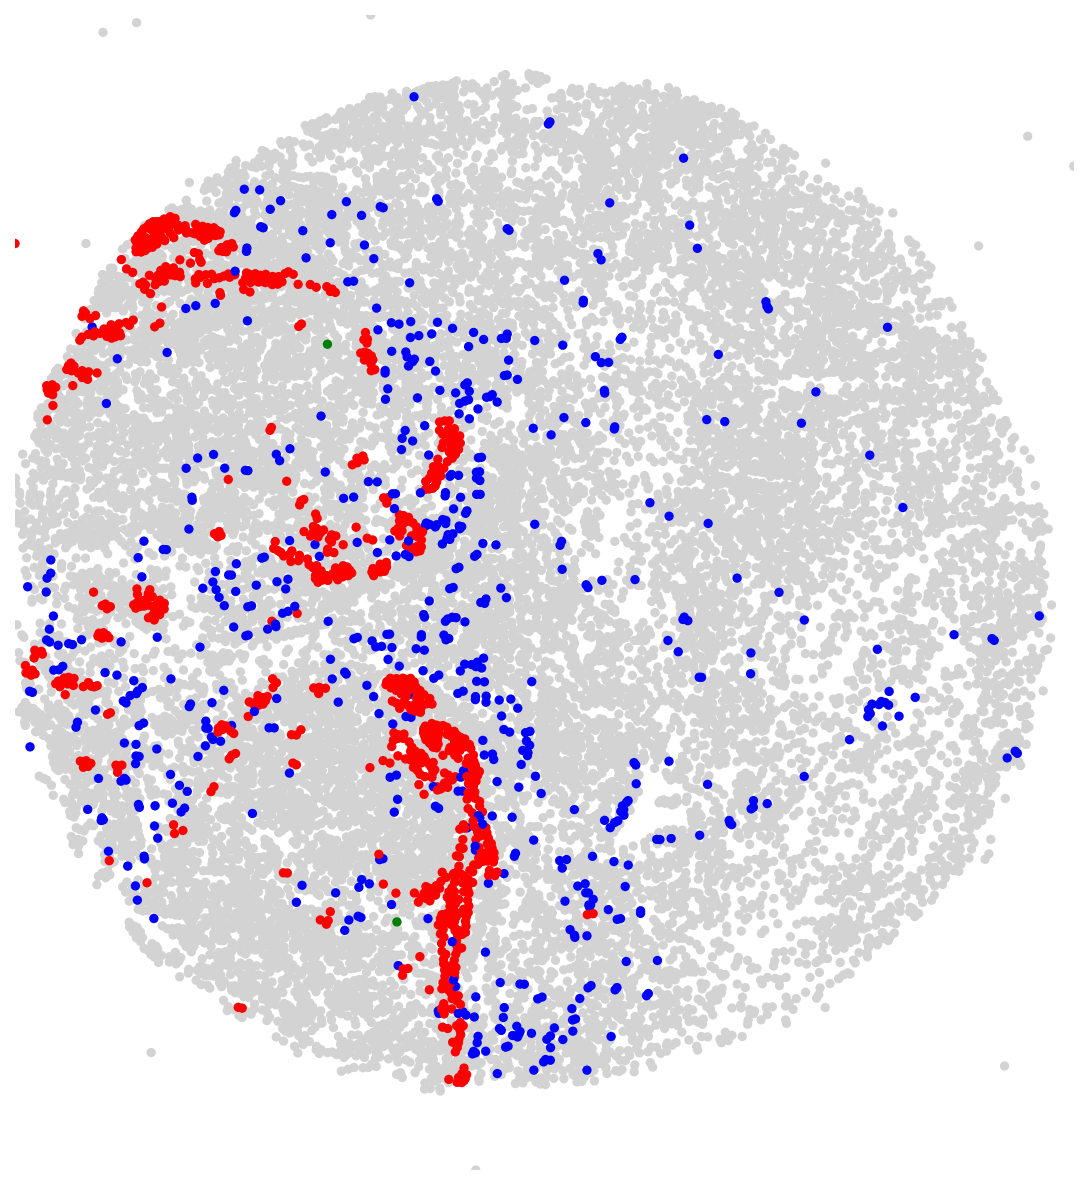

In [ ]:
plot_individual_category(adata[adata.obs['core_id'] == 43] , 'x_spatial_global' , 'phenograph_cluster' , [40, 34 , 45 ,16] , ['r','g','b','b'] , s = 4 , use_outlines = False)
                    
                    
                         

In [ ]:
adata.obs.head(4)

,core_id,cell_id,area,centroid_row_local,centroid_col_local,centroid_row_global,centroid_col_global,phenograph_cluster
0,0,1,326.0,50.365031,4060.981595,499.365031,4909.981595,75
1,0,2,496.0,82.040323,4022.814516,531.040323,4871.814516,75
2,0,3,289.0,82.145329,4060.204152,531.145329,4909.204152,75
3,0,4,214.0,131.056075,4036.345794,580.056075,4885.345794,75


# functions from José

In [ ]:

def divide_csr_matrix_gpu(mat, size_factor):
    """Divide csr matrix using gpu row-wise

    Params:
        - mat: np.array
        - size_factor: np.array
    Returns:
        np.array normalized matrix
    """
    mat = cupyx.scipy.sparse.csr_matrix(mat.astype(np.float32))
    c = cupyx.scipy.sparse.diags(1 / size_factor)
    result = c @ mat
    return result.get()


def neighbors_gpu(mat, k=30):
    """Compute knn on a matrix using gpu

    Params:
        - mat: np.array
        - k: number of nearest neighbors
    Returns:
        tuple: distances and indices of knn (array format)
    """
    X_mat = cupy.array(mat)
    model = cuml.neighbors.NearestNeighbors(n_neighbors=k)
    model.fit(X_mat)
    distances, indices = model.kneighbors(X_mat)
    return (distances, indices)


def get_cugraph_from_csr_matrix(mat):
    """Get cugraph from csr_matrix

    Params:
        - mat: scipy.csr_matrix
    Returns:
        cugraph representation of matrix
    """
    sources, targets = mat.nonzero()
    edges = cudf.concat(
        [
            cudf.Series(sources.astype(np.int64), name="source"),  # sources
            cudf.Series(targets.astype(np.int64), name="destination"),  # targets
        ],
        axis=1,
    )
    G = cugraph.from_cudf_edgelist(edges)
    return G


def get_cugraph_from_array(mat):
    """Get cugraph from array

    Params:
        - mat: list of lists in np.array format, each row in the array corresponds to the source node, values correspond to indexes the connected nodes. It assumes that the row indexes are in the same space as the values in the array.

    Returns
    -------
        cugraph representation of matrix
    """
    targets = np.ravel(mat)
    n_neighbors_per_cell = [len(x) for x in mat]
    sources = np.ravel([[i] * k for i, k in zip(range(mat.shape[0]), n_neighbors_per_cell)])
    edges = cudf.concat(
        [
            cudf.Series(sources.astype(np.int64), name="source"),  # sources
            cudf.Series(targets.astype(np.int64), name="destination"),  # targets
        ],
        axis=1,
    )
    G = cugraph.from_cudf_edgelist(edges)
    return (G, edges)


def array_to_csr_matrix(mat):
    """Get csr_matrix from list of list graph representation

    Params:
        - mat: list of lists in np.array format, each row in the array corresponds to the source node, values correspond to indexes the connected nodes. It assumes that the row indexes are in the same space as the values in the array.

    Returns
    -------
        csr_matrix representation of graph
    """
    targets = np.ravel(mat)
    n_neighbors_per_cell = [len(x) for x in mat]
    sources = np.ravel([[i] * k for i, k in zip(range(mat.shape[0]), n_neighbors_per_cell, strict=False)])
    result = scipy.sparse.csr_matrix(([1] * len(sources), (sources, targets)), shape=[mat.shape[0]] * 2)
    return result

def phenograph_gpu(
    G,
    min_size=-1,
    resolution=1.0,
):
    print("   Building Jaccard matrix")
    # Build jaccard-weighted graph in GPU
    jaccard_edges = cugraph.jaccard(G, edges[['source', 'destination']])
    G = cugraph.from_cudf_edgelist(jaccard_edges, *jaccard_edges.columns)

    print("   Finding clusters using louvain")
    # Cluster jaccard-weighted graph
    result, score = cugraph.louvain(G, resolution = resolution)

    # Sort clusters by size
    sizes = result['partition'].value_counts()
    sizes.loc[:] = cupy.where(sizes > min_size, cupy.arange(len(sizes)), -1)
    result['partition'] = result['partition'].map(sizes)

    # Sort by vertex (e.g. cell)
    clusters = result.sort_values('vertex')['partition'].values.get()
    return clusters

def get_jaccard(
    G,
):
    print("   Building Jaccard matrix")
    # Build jaccard-weighted graph in GPU
    jaccard_edges = cugraph.jaccard(G, edges[['source', 'destination']])
    G = cugraph.from_cudf_edgelist(jaccard_edges, *jaccard_edges.columns)
    return(G)

def louvain_gpu(G, min_size = 1, resolution=1.0):
    print("   Finding clusters using louvain")
    # Cluster jaccard-weighted graph
    result, score = cugraph.louvain(G, resolution = resolution)

    # Sort clusters by size
    sizes = result['partition'].value_counts()
    sizes.loc[:] = cupy.where(sizes > min_size, cupy.arange(len(sizes)), -1)
    result['partition'] = result['partition'].map(sizes)

    # Sort by vertex (e.g. cell)
    clusters = result.sort_values('vertex')['partition'].values.get()
    return clusters

def leiden_gpu(G, resolution=1.0):
    print("   Getting Leiden clusters")
    result, score = cugraph.leiden(G, max_iter = 100, resolution = resolution, random_state = 777)
    # Sort by vertex (e.g. cell)
    clusters = result.sort_values('vertex')['partition'].values.get()
    return(clusters)

def umap(
    X,
    n_neighbors = 30,
    min_dist = 0.05
):
    model = cuml.UMAP(
        min_dist=min_dist,
        spread=1,
        learning_rate=0.1,
        n_epochs=20000,
        n_neighbors = n_neighbors,
        verbose=True
    )
    X = cupy.array(X)
    model.fit(X=X)
    X_umap = model.transform(X)
    return(X_umap.get())

def quick_embed(adata_sub):
    frac_expressed = np.ravel((adata_sub.X > 0).sum(axis=0)) / adata_sub.n_obs
    adata_sub.var['excluded'] = np.logical_or(adata_sub.var['excluded'], frac_expressed <= 0.01)
    adata_sub = normalize_pca(adata_sub)
    total_var = 0.75
    n_pcs = np.argmin(abs(adata_sub.uns['pca_explained_var'].cumsum() - total_var))
    adata_sub.obsm['X_pca'] = adata_sub.obsm['X_pca_max'][:,:n_pcs].copy()
    distances, indices = neighbors_gpu(adata_sub.obsm['X_pca'])
    adata_sub.obsm['indices'] = indices.copy()
    G, edges = get_cugraph_from_array(indices)
    adata_sub.obs['Leiden_cluster'] = pd.Categorical(leiden_gpu(G))
    #adata_sub.obs['PhenoGraph_cluster'] = pd.Categorical(phenograph_gpu(G))
    #adata_sub.obsm['X_umap'] = umap(adata_sub.obsm['X_pca'])
    return(adata_sub)